In [22]:
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt

In [75]:
dataset = seaborn.load_dataset('titanic')
column_names = np.array(dataset.columns)
data = dataset.values
data = [row for row in data if (not np.isnan(row[3]))]
print(dataset)

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_town alive  alo

## Exploratory analysis

Text(0.5, 1.0, 'Survivors Male vs Female')

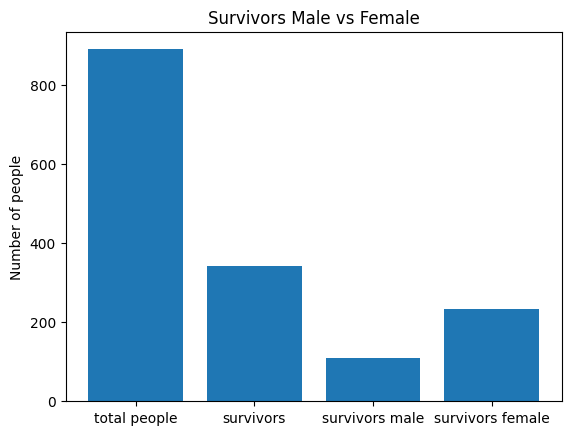

In [48]:
total_people = data.shape[0]
total_survivors = sum(data[:, 0])
total_survivors_male = sum(row[0] for row in data if row[2] == 'male')
total_survivors_female = sum(row[0] for row in data if row[2] == 'female')

plt.bar(['total people', 'survivors', 'survivors male', 'survivors female'],
        [total_people, total_survivors, total_survivors_male, total_survivors_female])
plt.ylabel('Number of people')
plt.title('Survivors Male vs Female')
        

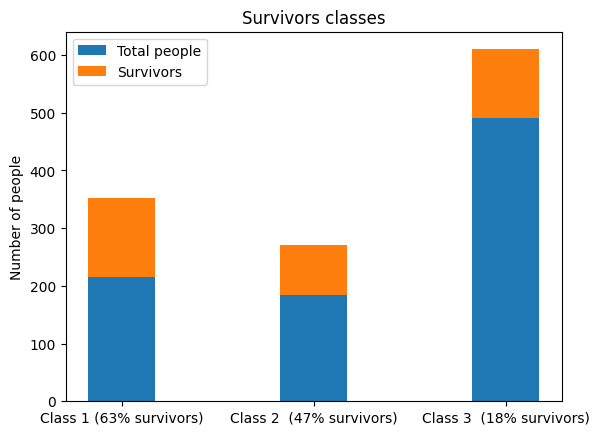

In [49]:
first_class_total = sum([1 for row in data if row[1] == 1])
second_class_total = sum([1 for row in data if row[1] == 2])
third_class_total = sum([1 for row in data if row[1] == 3])

first_class_survivors = sum([row[0] for row in data if row[1] == 1])
second_class_survivors = sum([row[0] for row in data if row[1] == 2])
third_class_survivors = sum([row[0] for row in data if row[1] == 3])

percentage1 = int(round(first_class_survivors /  first_class_total, 2) * 100)
percentage2 = int(round(second_class_survivors /  second_class_total, 2) * 100)
percentage3 = int(round(second_class_survivors /  third_class_total, 2) * 100)

width = 0.35

plt.bar(['Class 1 (' + str(percentage1) + '% survivors)', 'Class 2  (' + str(percentage2) + '% survivors)', 'Class 3  (' + str(percentage3) + '% survivors)'],
        [first_class_total, second_class_total, third_class_total],
        width,
        label='Total people',)
plt.bar(['Class 1 (' + str(percentage1) + '% survivors)', 'Class 2  (' + str(percentage2) + '% survivors)', 'Class 3  (' + str(percentage3) + '% survivors)'],
        [first_class_survivors, second_class_survivors, third_class_survivors],
        width,
        bottom = [first_class_total, second_class_total, third_class_total],
        label='Survivors')

plt.ylabel('Number of people')
plt.title('Survivor classes')
plt.legend()

### Age distribution

Text(0.5, 1.0, 'Age Distribution of survivors')

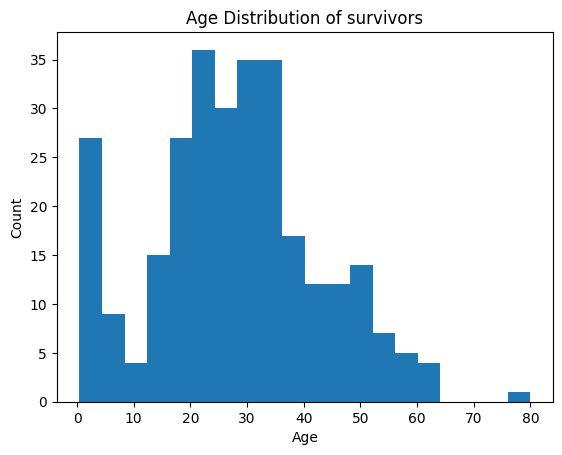

In [76]:
ages = [row[3] for row in data if row[0] == 1]

plt.hist(ages, bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution of survivors")

### Feature correlation

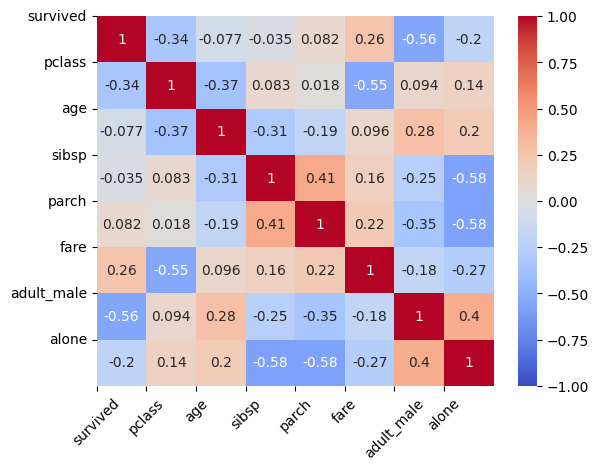

In [88]:
corr = dataset.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)


plt.show()